In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [6]:
!kaggle datasets download -d salader/dogs-vs-cats

Dataset URL: https://www.kaggle.com/datasets/salader/dogs-vs-cats
License(s): unknown
100% 1.06G/1.06G [00:08<00:00, 331MB/s]
100% 1.06G/1.06G [00:08<00:00, 135MB/s]


In [7]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogs-vs-cats.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [8]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from keras.layers import Dense, Flatten
from keras.applications.vgg16 import VGG16

## Model Building

In [9]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(150, 150, 3)
)

conv_base.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [10]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [11]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

In [13]:
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale = 1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

In [14]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [15]:
train_generator = train_datagen.flow_from_directory(
    '/content/dogs_vs_cats/train',
    target_size=(150, 150),
    batch_size=batch_size,
    class_mode = 'binary'
)

Found 20000 images belonging to 2 classes.


In [16]:
validation_generator = test_datagen.flow_from_directory(
    '/content/dogs_vs_cats/test',
    target_size=(150, 150),
    batch_size=batch_size,
    class_mode = 'binary'
)

Found 5000 images belonging to 2 classes.


## Training

In [17]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 168s 254ms/step - accuracy: 0.8235 - loss: 0.4098 - val_accuracy: 0.8982 - val_loss: 0.2374
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 154s 246ms/step - accuracy: 0.8957 - loss: 0.2345 - val_accuracy: 0.9040 - val_loss: 0.2184
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 156s 249ms/step - accuracy: 0.9040 - loss: 0.2223 - val_accuracy: 0.9160 - val_loss: 0.1979
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 155s 247ms/step - accuracy: 0.9120 - loss: 0.2048 - val_accuracy: 0.9138 - val_loss: 0.1977
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 155s 248ms/step - accuracy: 0.9142 - loss: 0.2033 - val_accuracy: 0.9140 - val_loss: 0.1988
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 158s 253ms/step - accuracy: 0.9178 - loss: 0.1925 - val_accuracy: 0.9162 - val_loss: 0.1878
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 197s 245ms/step - accuracy: 0.9216 - loss: 0.1866 - val_accuracy: 0.9092 - val_loss: 0.2330
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 155s 248ms/step - accuracy: 0.9283 -

In [28]:
model.save('Cat_vs_Dog_Classifier.h5')

In [19]:
import cv2
import numpy as np
from keras.models import load_model
import matplotlib.pyplot as plt

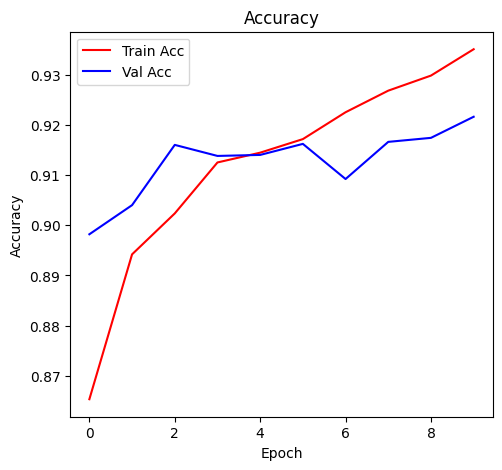

In [20]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], 'r', label='Train Acc')
plt.plot(history.history['val_accuracy'], 'b', label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

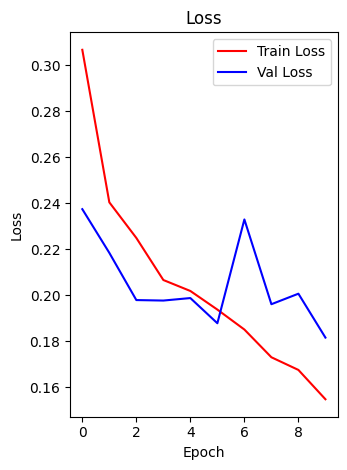

In [21]:
plt.subplot(1,2,2)
plt.plot(history.history['loss'], 'r', label='Train Loss')
plt.plot(history.history['val_loss'], 'b', label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Evaluation: Confusion Matrix (on validation data)

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [23]:
val_generator_for_eval = test_datagen.flow_from_directory(
    '/content/dogs_vs_cats/test',
    target_size=(150, 150),
    batch_size=1,
    class_mode='binary',
    shuffle=False
)

Found 5000 images belonging to 2 classes.


In [24]:
val_preds = model.predict(val_generator_for_eval)
val_pred_classes = (val_preds > 0.5).astype(int).reshape(-1)
val_true_classes = val_generator_for_eval.classes

5000/5000 ━━━━━━━━━━━━━━━━━━━━ 38s 7ms/step


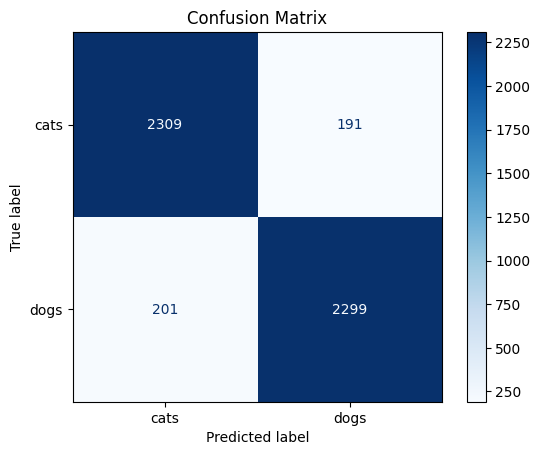

In [25]:
cm = confusion_matrix(val_true_classes, val_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=val_generator_for_eval.class_indices)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

## Test

In [33]:
def predict_image(image_path, model):
    test_img = cv2.imread(image_path)
    plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    img = cv2.resize(test_img, (150, 150))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    prediction = model.predict(img)
    class_name = "Dog" if prediction[0][0] > 0.5 else "Cat"
    print(f"Prediction Score: {prediction[0][0]:.4f}")
    print(f"Predicted Class: {class_name}")

In [ ]:
model = load_model('Cat_vs_Dog_Classifier.h5')

In [38]:
# Load and preprocess image
test_img = '/content/download.jpeg'
predict_image(test_img, model)

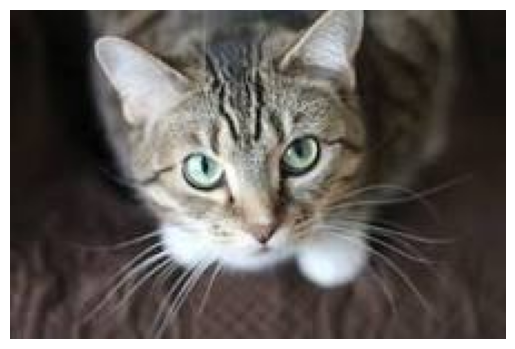

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Prediction Score: 0.0000
Predicted Class: Cat


In [41]:
# Load and preprocess image
test_img2 ='/content/down.jpeg'
predict_image(test_img2, model)